LSTM Neural Network Model Experiments for Binary Classification
---
Performs grid search on 64 different configurations to determine the best (Bi)LSTM NN model for classifcation between Healthy Control (0) and Cognitively Impaired (1), which combines the MCI and Dementia classes.

Grid search is run on all three transcript types to determine the best model for each PFT, CTD, and SFT.

**Instructions**: Run the cells in order to load the data, tokenize and pad text, and execute grid search. After grid search is executed, the best configuration is determined from the highest mean macro F1 scores for each transcript and that model is rerun to generate the confusion matrices and reports. 

In [3]:
import sys
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer

sys.path.append(str(Path("..").resolve()))

from transcript_preprocessing import load_transcript_splits

DATA_PATH = Path("..") / "data" / "transcripts_cleaned.csv"
TRANSCRIPT_COLS = ["Transcript_PFT", "Transcript_CTD", "Transcript_SFT"]

transcript_df = pd.read_csv(DATA_PATH)

df_by_transcript = load_transcript_splits(DATA_PATH)

# confirm data loaded in correctly
for col in TRANSCRIPT_COLS:
    print(f"After removing NaNs for {col}: {len(df_by_transcript[col])} samples")
transcript_df.head()

After removing NaNs for Transcript_PFT: 157 samples
After removing NaNs for Transcript_CTD: 156 samples
After removing NaNs for Transcript_SFT: 152 samples


,Record-ID,Class,Transcript_PFT,Transcript_CTD,Transcript_SFT,Label,Binary_Label
0,Process-rec-001,MCI,"people, partner, plate, platter, pants, porter...",NaN,"<pause_medium> giraffe, kangaroo, lion, tiger,...",1,1
1,Process-rec-002,MCI,"<pause_short> pipe, plane, people <pause_mediu...",<pause_medium> there’s a lad stood on the stoo...,"<pause_short> dogs, cats, birds <pause_short> ...",1,1
2,Process-rec-003,MCI,"um <pause_short> purple, pale, placid <pause_s...","<pause_medium> um, the picture is of a kitchen...","cow, bull, ewe, ram, chicken, goose, um <sigh>...",1,1
3,Process-rec-004,MCI,plank <pause_short> pool <pause_short> swimmin...,"a mother presumably, or a fe, an adult female ...",um <pause_short> impala <pause_short> er cheet...,1,1
4,Process-rec-005,MCI,"it’s er pillock, er post box, er pyracanthas, ...","‘50s style er scene of domestic um confusion, ...","dog, cat, giraffe, wallaby, kangaroo, tortoise...",1,1


In [12]:
from utils import make_config_grid

# Hyperparameter options for grid search
MODEL_TYPES = ["lstm", "bilstm"]
EMBEDDING_DIMS = [100, 200]
LSTM_UNITS = [16, 128]
DROPOUT_RATES = [0.3]
RECURRENT_DROPOUT_RATES = [0.0, 0.1]
DENSE_UNITS_OPTIONS = [0, 64]  # 0 = no dense layer, 64 = add dense hidden layer
LEARNING_RATES = [1e-3, 5e-4]

config_grid = make_config_grid(
    MODEL_TYPES,
    EMBEDDING_DIMS,
    LSTM_UNITS,
    DROPOUT_RATES,
    RECURRENT_DROPOUT_RATES,
    DENSE_UNITS_OPTIONS,
    LEARNING_RATES,
)
print(f"Total configs: {len(config_grid)}")

Total configs: 64


In [15]:
from typing import Dict
from sklearn.utils.class_weight import compute_class_weight
from keras.callbacks import EarlyStopping
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

from transcript_preprocessing import get_stratified_kfold_splits
from utils import prepare_fold_data, build_binary_lstm_model


def run_binary_cv_for_config(
    transcript_col: str,
    df: pd.DataFrame,
    config: Dict,
    max_len: int,
    n_splits: int = 5,
    seed: int = 42,
    batch_size: int = 16,
    max_epochs: int = 30,
):
    """
    Run stratified K-fold CV for a single transcript type and binary config.

    Returns:
        metrics_dict: dict with overall mean/std metrics across folds.
    """
    accuracies = []
    macro_f1s = []
    weighted_f1s = []
    precision_macros = []
    recall_macros = []

    # For each fold
    for fold_idx, train_idx, val_idx in get_stratified_kfold_splits(
        transcript_df=df,
        transcript_col=transcript_col,
        label_col="Binary_Label",
        n_splits=n_splits,
        seed=seed,
    ):
        X_train, y_train, X_val, y_val, tokenizer, vocab_size = prepare_fold_data(
            df=df,
            transcript_col=transcript_col,
            label_col="Binary_Label",
            train_idx=train_idx,
            val_idx=val_idx,
            max_len=max_len,
        )

        model = build_binary_lstm_model(
            config=config,
            vocab_size=vocab_size,
            max_len=max_len,
        )

        # Class weights for HC vs Impaired
        classes = np.unique(y_train)
        class_weights_array = compute_class_weight(
            class_weight="balanced",
            classes=classes,
            y=y_train,
        )
        class_weight = {int(c): float(w) for c, w in zip(classes, class_weights_array)}

        callbacks = [
            EarlyStopping(
                monitor="val_loss",
                patience=3,
                restore_best_weights=True,
                verbose=0,
            )
        ]

        model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=max_epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=0,
            class_weight=class_weight,
        )

        # Predict probabilities, then threshold at 0.5
        y_prob = model.predict(X_val, batch_size=batch_size, verbose=0).flatten()
        y_pred = (y_prob >= 0.5).astype(int)

        acc = accuracy_score(y_val, y_pred)
        macro_f1 = f1_score(y_val, y_pred, average="macro", zero_division=0)
        weighted_f1 = f1_score(y_val, y_pred, average="weighted", zero_division=0)
        precision_macro, recall_macro, _, _ = precision_recall_fscore_support(
            y_val, y_pred, average="macro", zero_division=0
        )

        accuracies.append(acc)
        macro_f1s.append(macro_f1)
        weighted_f1s.append(weighted_f1)
        precision_macros.append(precision_macro)
        recall_macros.append(recall_macro)

    metrics = {
        "mean_accuracy": float(np.mean(accuracies)),
        "std_accuracy": float(np.std(accuracies, ddof=1)),
        "mean_macro_f1": float(np.mean(macro_f1s)),
        "std_macro_f1": float(np.std(macro_f1s, ddof=1)),
        "mean_weighted_f1": float(np.mean(weighted_f1s)),
        "std_weighted_f1": float(np.std(weighted_f1s, ddof=1)),
        "mean_precision_macro": float(np.mean(precision_macros)),
        "std_precision_macro": float(np.std(precision_macros, ddof=1)),
        "mean_recall_macro": float(np.mean(recall_macros)),
        "std_recall_macro": float(np.std(recall_macros, ddof=1)),
    }
    return metrics

In [ ]:
# Suppress TensorFlow warnings
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

MAX_LEN_BY_TRANSCRIPT = {
    "Transcript_PFT": 94,
    "Transcript_CTD": 474,
    "Transcript_SFT": 121,
}

all_results = []

# main grid search loop
# NOTE: This took ~4 hours to run
for transcript_col in TRANSCRIPT_COLS:
    print(f"\nBinary grid search for {transcript_col}: ")
    df_t = df_by_transcript[transcript_col]
    max_len = MAX_LEN_BY_TRANSCRIPT[transcript_col]

    for i, config in enumerate(config_grid):
        print(f"\n[{transcript_col}] Config {i}: {config}")

        metrics = run_binary_cv_for_config(
            transcript_col=transcript_col,
            df=df_t,
            config=config,
            max_len=max_len,
            n_splits=5,
            seed=42,
            batch_size=16,
            max_epochs=30,
        )

        row = {
            "transcript_col": transcript_col,
            "model_type": config["model_type"],
            "embedding_dim": config["embedding_dim"],
            "lstm_units": config["lstm_units"],
            "dropout": config["dropout"],
            "recurrent_dropout": config["recurrent_dropout"],
            "dense_units": config["dense_units"],
            "learning_rate": config["learning_rate"],
        }
        row.update(metrics)
        all_results.append(row)

# Convert to DataFrame and save
binary_results_df = pd.DataFrame(all_results)
binary_results_df.to_csv("binary_lstm_bilstm_grid_search_results.csv", index=False)

# Show top 5 configs per transcript by mean_macro_f1
display(
    binary_results_df.sort_values(
        ["transcript_col", "mean_macro_f1"],
        ascending=[True, False],
    ).groupby("transcript_col").head(5)
)


Binary grid search for Transcript_PFT: 

[Transcript_PFT] Config 0: {'model_type': 'lstm', 'embedding_dim': 100, 'lstm_units': 16, 'dropout': 0.3, 'recurrent_dropout': 0.0, 'dense_units': 0, 'learning_rate': 0.001}

[Transcript_PFT] Config 1: {'model_type': 'lstm', 'embedding_dim': 100, 'lstm_units': 16, 'dropout': 0.3, 'recurrent_dropout': 0.0, 'dense_units': 0, 'learning_rate': 0.0005}

[Transcript_PFT] Config 2: {'model_type': 'lstm', 'embedding_dim': 100, 'lstm_units': 16, 'dropout': 0.3, 'recurrent_dropout': 0.0, 'dense_units': 64, 'learning_rate': 0.001}

[Transcript_PFT] Config 3: {'model_type': 'lstm', 'embedding_dim': 100, 'lstm_units': 16, 'dropout': 0.3, 'recurrent_dropout': 0.0, 'dense_units': 64, 'learning_rate': 0.0005}

[Transcript_PFT] Config 4: {'model_type': 'lstm', 'embedding_dim': 100, 'lstm_units': 16, 'dropout': 0.3, 'recurrent_dropout': 0.1, 'dense_units': 0, 'learning_rate': 0.001}

[Transcript_PFT] Config 5: {'model_type': 'lstm', 'embedding_dim': 100, 'lstm_u

,transcript_col,model_type,embedding_dim,lstm_units,dropout,recurrent_dropout,dense_units,learning_rate,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1,mean_weighted_f1,std_weighted_f1,mean_precision_macro,std_precision_macro,mean_recall_macro,std_recall_macro
123,Transcript_CTD,bilstm,200,128,0.3,0.0,64,0.0005,0.705645,0.053036,0.692766,0.068337,0.696017,0.065332,0.717839,0.042630,0.698564,0.059583
101,Transcript_CTD,bilstm,100,16,0.3,0.1,0,0.0005,0.692944,0.112406,0.686386,0.114512,0.688444,0.113895,0.699020,0.111291,0.689083,0.112927
103,Transcript_CTD,bilstm,100,16,0.3,0.1,64,0.0005,0.686290,0.090182,0.678601,0.098392,0.681338,0.095353,0.687694,0.090274,0.681523,0.094911
117,Transcript_CTD,bilstm,200,16,0.3,0.1,0,0.0005,0.672581,0.088269,0.669905,0.089351,0.671386,0.088672,0.673034,0.090856,0.670452,0.088961
127,Transcript_CTD,bilstm,200,128,0.3,0.1,64,0.0005,0.673589,0.080090,0.662474,0.083206,0.665420,0.081548,0.686933,0.092839,0.667486,0.081721
52,Transcript_PFT,bilstm,200,16,0.3,0.1,0,0.0010,0.573992,0.080069,0.568530,0.078429,0.567146,0.078075,0.587879,0.087776,0.578554,0.081633
4,Transcript_PFT,lstm,100,16,0.3,0.1,0,0.0010,0.592540,0.062599,0.568121,0.091873,0.564441,0.097527,0.622612,0.045494,0.600686,0.053464
58,Transcript_PFT,bilstm,200,128,0.3,0.0,64,0.0010,0.585685,0.096042,0.558945,0.105296,0.562943,0.103392,0.599017,0.113573,0.578358,0.097538
17,Transcript_PFT,lstm,200,16,0.3,0.0,0,0.0005,0.579839,0.104105,0.558837,0.095896,0.559783,0.099860,0.613221,0.142893,0.577328,0.094420
21,Transcript_PFT,lstm,200,16,0.3,0.1,0,0.0005,0.574194,0.085616,0.558803,0.082590,0.555751,0.083541,0.613922,0.124643,0.582206,0.086197


In [ ]:
binary_best_configs: Dict[str, Dict] = {}

for col in TRANSCRIPT_COLS:
    subset = binary_results_df[binary_results_df["transcript_col"] == col]
    # pick row with highest mean_macro_f1
    best_row = subset.sort_values("mean_macro_f1", ascending=False).iloc[0]

    cfg = {
        "model_type": str(best_row["model_type"]),
        "embedding_dim": int(best_row["embedding_dim"]),
        "lstm_units": int(best_row["lstm_units"]),
        "dropout": float(best_row["dropout"]),
        "recurrent_dropout": float(best_row["recurrent_dropout"]),
        "dense_units": int(best_row["dense_units"]),
        "learning_rate": float(best_row["learning_rate"]),
    }

    binary_best_configs[col] = cfg

    print(f"\nBest binary config for {col}:")
    print(cfg)
    print("mean_macro_f1:", best_row["mean_macro_f1"])


Best binary config for Transcript_PFT:
{'model_type': 'bilstm', 'embedding_dim': 200, 'lstm_units': 16, 'dropout': 0.3, 'recurrent_dropout': 0.1, 'dense_units': 0, 'learning_rate': 0.001}
mean_macro_f1: 0.5685295127455371

Best binary config for Transcript_CTD:
{'model_type': 'bilstm', 'embedding_dim': 200, 'lstm_units': 128, 'dropout': 0.3, 'recurrent_dropout': 0.0, 'dense_units': 64, 'learning_rate': 0.0005}
mean_macro_f1: 0.6927659678805396

Best binary config for Transcript_SFT:
{'model_type': 'bilstm', 'embedding_dim': 200, 'lstm_units': 128, 'dropout': 0.3, 'recurrent_dropout': 0.0, 'dense_units': 0, 'learning_rate': 0.001}
mean_macro_f1: 0.6752127175656588


In [19]:
def run_binary_cv_collect_predictions(
    transcript_col: str,
    df: pd.DataFrame,
    config: Dict,
    max_len: int,
    n_splits: int = 5,
    seed: int = 42,
    batch_size: int = 16,
    max_epochs: int = 30,
):
    """Re-run CV for a given transcript/config and collect pooled predictions."""
    all_true = []
    all_pred = []
    fold_metrics = []

    for fold_idx, train_idx, val_idx in get_stratified_kfold_splits(
        transcript_df=df,
        transcript_col=transcript_col,
        label_col="Binary_Label",
        n_splits=n_splits,
        seed=seed,
    ):
        X_train, y_train, X_val, y_val, tokenizer, vocab_size = prepare_fold_data(
            df=df,
            transcript_col=transcript_col,
            label_col="Binary_Label",
            train_idx=train_idx,
            val_idx=val_idx,
            max_len=max_len,
        )

        model = build_binary_lstm_model(
            config=config,
            vocab_size=vocab_size,
            max_len=max_len,
        )

        classes = np.unique(y_train)
        class_weights_array = compute_class_weight(
            class_weight="balanced",
            classes=classes,
            y=y_train,
        )
        class_weight = {int(c): float(w) for c, w in zip(classes, class_weights_array)}

        callbacks = [
            EarlyStopping(
                monitor="val_loss",
                patience=3,
                restore_best_weights=True,
                verbose=0,
            )
        ]

        model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=max_epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=0,
            class_weight=class_weight,
        )

        y_prob = model.predict(X_val, batch_size=batch_size, verbose=0).flatten()
        y_pred = (y_prob >= 0.5).astype(int)

        all_true.append(y_val)
        all_pred.append(y_pred)

        acc = accuracy_score(y_val, y_pred)
        macro_f1 = f1_score(y_val, y_pred, average="macro", zero_division=0)
        fold_metrics.append({"fold": fold_idx, "accuracy": acc, "macro_f1": macro_f1})

    y_true_all = np.concatenate(all_true)
    y_pred_all = np.concatenate(all_pred)

    return y_true_all, y_pred_all, fold_metrics



Binary confusion matrix for Transcript_PFT:


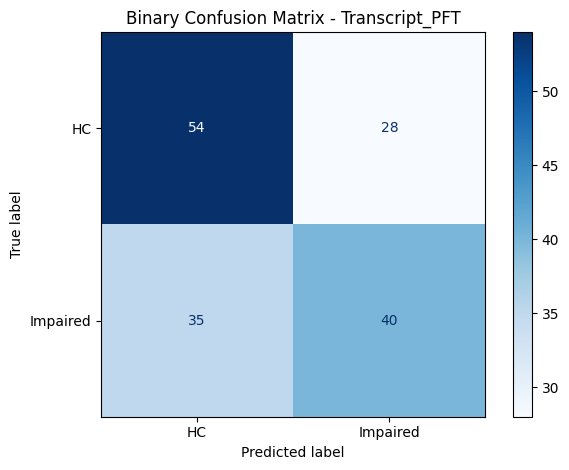

Classification report (binary):
              precision    recall  f1-score   support

          HC       0.61      0.66      0.63        82
    Impaired       0.59      0.53      0.56        75

    accuracy                           0.60       157
   macro avg       0.60      0.60      0.60       157
weighted avg       0.60      0.60      0.60       157

Mean accuracy over folds: 0.599
Mean macro F1 over folds: 0.592

Binary confusion matrix for Transcript_CTD:


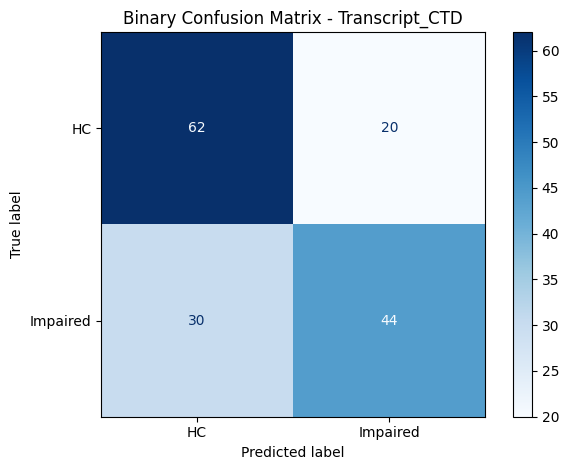

Classification report (binary):
              precision    recall  f1-score   support

          HC       0.67      0.76      0.71        82
    Impaired       0.69      0.59      0.64        74

    accuracy                           0.68       156
   macro avg       0.68      0.68      0.68       156
weighted avg       0.68      0.68      0.68       156

Mean accuracy over folds: 0.680
Mean macro F1 over folds: 0.669

Binary confusion matrix for Transcript_SFT:


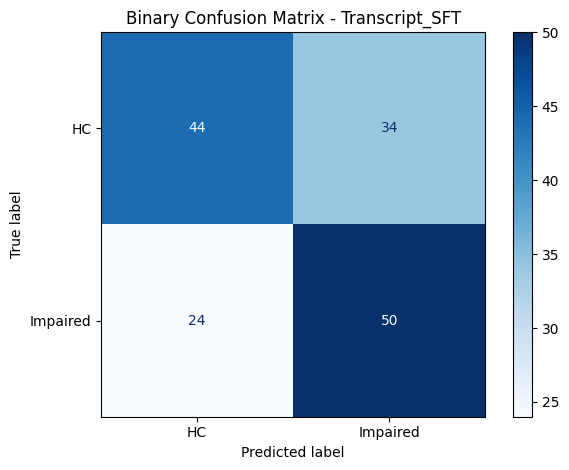

Classification report (binary):
              precision    recall  f1-score   support

          HC       0.65      0.56      0.60        78
    Impaired       0.60      0.68      0.63        74

    accuracy                           0.62       152
   macro avg       0.62      0.62      0.62       152
weighted avg       0.62      0.62      0.62       152

Mean accuracy over folds: 0.620
Mean macro F1 over folds: 0.616


In [ ]:
# Build confusion matrices and classification reports for the best configs for each transcript type
# NOTE: This fully retrains the model with new random initialization, resulting in different F1 scores than during grid search

CLASS_NAMES_BINARY = ["HC", "Impaired"]

for transcript_col in TRANSCRIPT_COLS:
    print(f"\nBinary confusion matrix for {transcript_col}:")

    df_t = df_by_transcript[transcript_col]
    max_len = MAX_LEN_BY_TRANSCRIPT[transcript_col]
    config = binary_best_configs[transcript_col]

    y_true, y_pred, fold_metrics = run_binary_cv_collect_predictions(
        transcript_col=transcript_col,
        df=df_t,
        config=config,
        max_len=max_len,
        n_splits=5,
        seed=42,
        batch_size=16,
        max_epochs=30,
    )

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    fig, ax = plt.subplots()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES_BINARY)
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Binary Confusion Matrix - {transcript_col}")
    plt.tight_layout()
    # Save confusion matrix
    filename = f"binary_confusion_matrix_{transcript_col}.png"
    fig.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

    print("Classification report (binary):")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES_BINARY, zero_division=0))

    accs = [m["accuracy"] for m in fold_metrics]
    macros = [m["macro_f1"] for m in fold_metrics]
    print(f"Mean accuracy over folds: {np.mean(accs):.3f}")
    print(f"Mean macro F1 over folds: {np.mean(macros):.3f}")